# Projeto MEGA - Análise de Volume e ROI
Este notebook identifica as categorias e filiais com maior volume de registros para focar a análise de séries temporais.

In [35]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Configurações de Carga
target_file = 'data/database_final.csv'
df = pd.read_csv(target_file, low_memory=False)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

print(f"Tamanho do DataFrame original: {df.shape}")

Tamanho do DataFrame original: (556198, 13)


## 1. Identificação da Categoria e Filial por Volume

In [36]:
analise_volume = df.groupby(['CATEGORIA', 'FILIAL']).agg(
    TOTAL_REGISTROS=('SKU', 'count'),
    FATUR_TOTAL=('FATUR_VENDA', 'sum')
).reset_index()

melhor_foco = analise_volume.sort_values(by='TOTAL_REGISTROS', ascending=False).iloc[0]

print(f"Foco definido: {melhor_foco['CATEGORIA']} na {melhor_foco['FILIAL']}")

Foco definido: Temperos & Condimentos na SHOPPING


## 2. Filtragem e Agregação Diária

In [37]:
cat_alvo = melhor_foco['CATEGORIA']
filial_alvo = melhor_foco['FILIAL']

df_filtrado = df[(df['CATEGORIA'] == cat_alvo) & (df['FILIAL'] == filial_alvo)].copy()

df_treino = df_filtrado.groupby('DATA_ATEND').agg(
    DEMANDA_ALVO=('FATUR_VENDA', 'sum')
).reset_index()

print(f"Série temporal gerada: {df_treino.shape[0]} observações diárias.")

Série temporal gerada: 362 observações diárias.


## 3. Análise Visual (EDA)
Aqui visualizamos o comportamento da demanda ao longo do tempo e identificamos padrões sazonais.

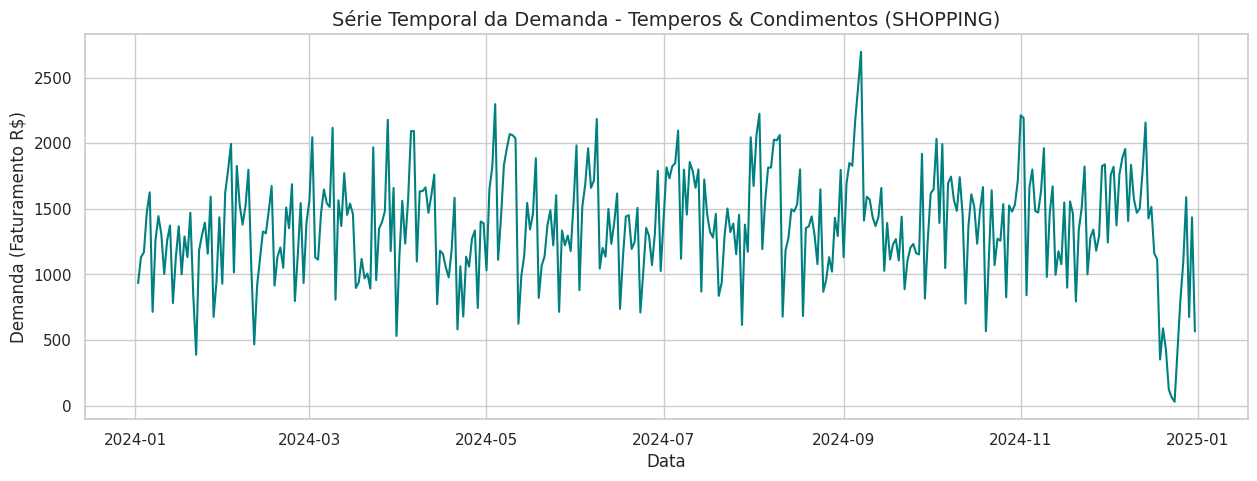

In [38]:
# A. Comportamento da Demanda ao Longo do Tempo
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_treino, x='DATA_ATEND', y='DEMANDA_ALVO', color='teal', linewidth=1.5)
plt.title(f'Série Temporal da Demanda - {cat_alvo} ({filial_alvo})', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Demanda (Faturamento R$)', fontsize=12)
plt.show()

/tmp/ipykernel_1960589/2166808593.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_treino, x='DIA_SEMANA', y='DEMANDA_ALVO', order=ordem_dias, ax=axes[0], palette='viridis')
/tmp/ipykernel_1960589/2166808593.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_treino, x='MES', y='DEMANDA_ALVO', ax=axes[1], palette='magma')


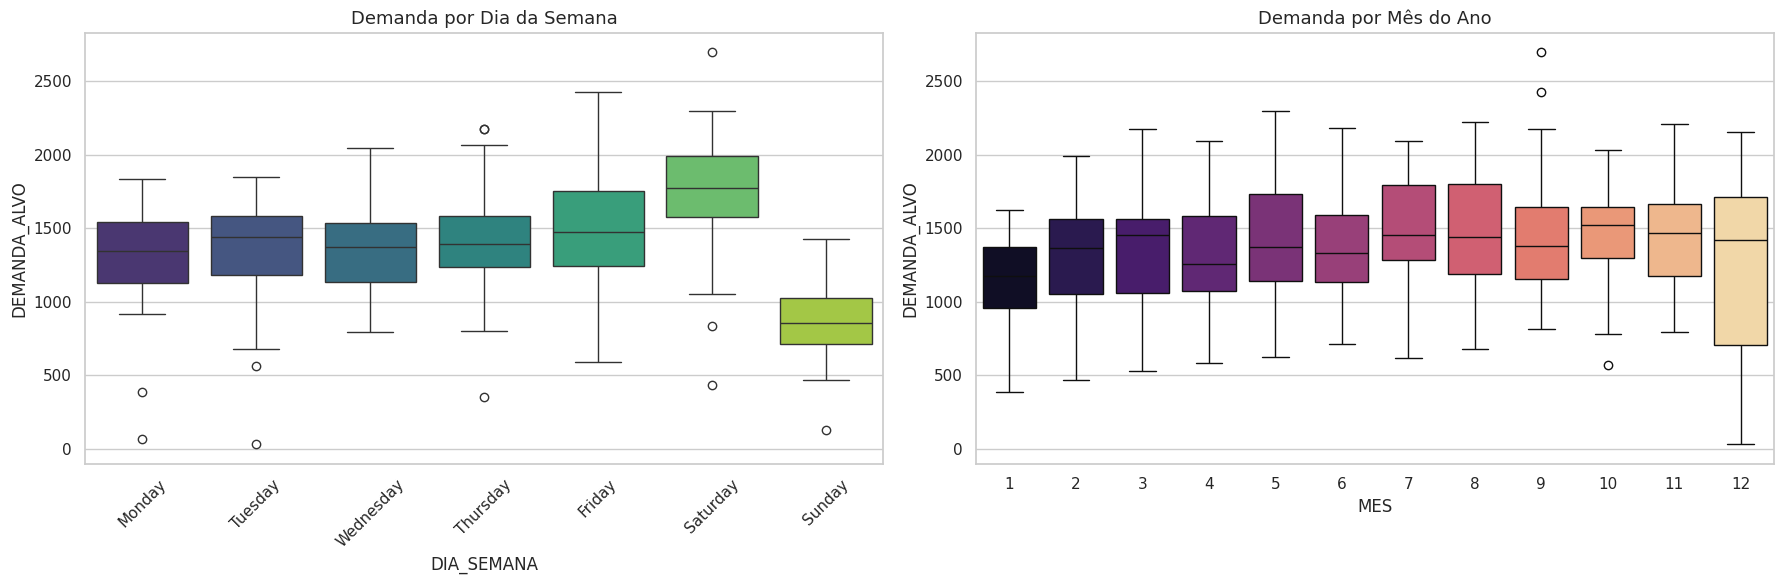

In [39]:
# B. Sazonalidade (Dia da Semana e Mês)
df_treino['MES'] = df_treino['DATA_ATEND'].dt.month
df_treino['DIA_SEMANA'] = df_treino['DATA_ATEND'].dt.day_name()
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_treino, x='DIA_SEMANA', y='DEMANDA_ALVO', order=ordem_dias, ax=axes[0], palette='viridis')
axes[0].set_title('Demanda por Dia da Semana', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_treino, x='MES', y='DEMANDA_ALVO', ax=axes[1], palette='magma')
axes[1].set_title('Demanda por Mês do Ano', fontsize=13)

plt.tight_layout()
plt.show()

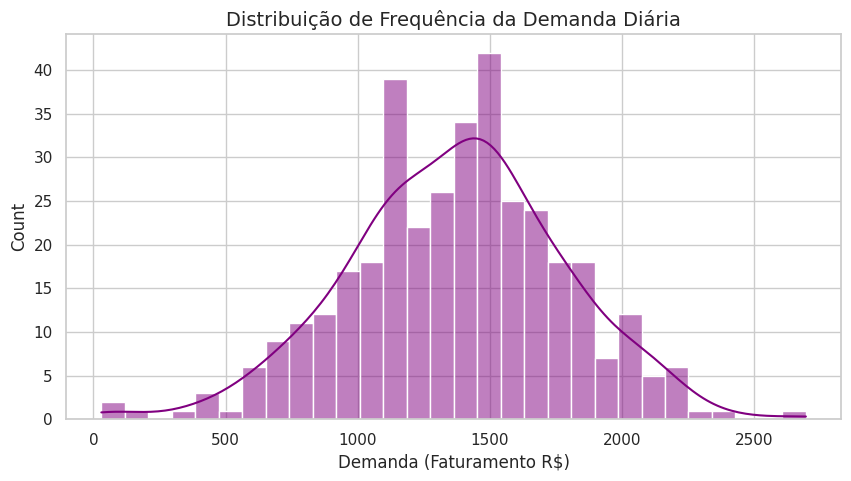

In [40]:
# C. Distribuição da Demanda (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(df_treino['DEMANDA_ALVO'], kde=True, color='purple', bins=30)
plt.title('Distribuição de Frequência da Demanda Diária', fontsize=14)
plt.xlabel('Demanda (Faturamento R$)', fontsize=12)
plt.show()

## 4. Definição de Níveis (Thresholds)
Usaremos quantis para classificar a Demanda em Baixa, Média e Alta. Esses valores servirão de base para as decisões de Estoque.

In [41]:
# Cálculo dos Quantis
q33 = df_treino['DEMANDA_ALVO'].quantile(0.33)
q66 = df_treino['DEMANDA_ALVO'].quantile(0.66)
v_max = df_treino['DEMANDA_ALVO'].max()

print("=== DEFINIÇÃO DE LIMITES PARA A ÁRVORE DE DECISÃO ===")
print(f"Demanda BAIXA: Até R$ {q33:.2f}")
print(f"Demanda MÉDIA: Entre R$ {q33:.2f} e R$ {q66:.2f}")
print(f"Demanda ALTA: Acima de R$ {q66:.2f} (Máximo histórico: R$ {v_max:.2f})")

print("\n--- Sugestão de Lotes de Estoque (Decisões) ---")
print(f"1. Estoque PEQUENO:  {q33:.2f} (Cobre demanda baixa)")
print(f"2. Estoque MÉDIO:    {q66:.2f} (Cobre demanda média)")
print(f"3. Estoque GRANDE:   {v_max:.2f} (Cobre demanda alta)")

=== DEFINIÇÃO DE LIMITES PARA A ÁRVORE DE DECISÃO ===
Demanda BAIXA: Até R$ 1184.24
Demanda MÉDIA: Entre R$ 1184.24 e R$ 1525.64
Demanda ALTA: Acima de R$ 1525.64 (Máximo histórico: R$ 2696.45)

--- Sugestão de Lotes de Estoque (Decisões) ---
1. Estoque PEQUENO:  1184.24 (Cobre demanda baixa)
2. Estoque MÉDIO:    1525.64 (Cobre demanda média)
3. Estoque GRANDE:   2696.45 (Cobre demanda alta)
